(200, 2) (200, 1)


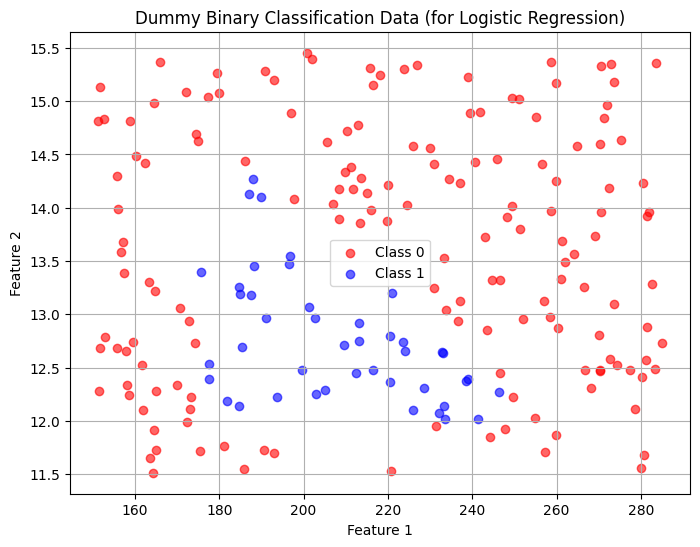

In [33]:
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt

def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return (X, Y.reshape(-1,1))

X,y = load_coffee_data()
print(X.shape, y.shape)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X[y.flatten() == 0][:, 0], X[y.flatten() == 0][:, 1], color="red", label="Class 0", alpha=0.6)
plt.scatter(X[y.flatten() == 1][:, 0], X[y.flatten() == 1][:, 1], color="blue", label="Class 1", alpha=0.6)
plt.title("Dummy Binary Classification Data (for Logistic Regression)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


In [34]:
import numpy as np

# 1. Pure Math se Feature Normalization
# Formula: (X - Mean) / Standard Deviation
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
Xn = (X - X_mean) / X_std

print(f"Temp Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Dur  Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}\n")

# 2. Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 3. Parameters (Weights aur Bias) Initialize karte hain
m, n = Xn.shape  
np.random.seed(42)
W = np.random.randn(n, 1) * 0.01  
b = 0.0                           

# Hyperparameters
learning_rate = 0.5
epochs = 1000
costs = [] 

# 4. Gradient Descent ka Main Loop
for i in range(epochs):
    
    # --- FORWARD PROPAGATION ---
    Z = np.dot(Xn, W) + b         
    A = sigmoid(Z)                
    
    # --- COST (LOSS) CALCULATION ---
    epsilon = 1e-15
    cost = -1/m * np.sum(y * np.log(A + epsilon) + (1 - y) * np.log(1 - A + epsilon))
    costs.append(cost)
    
    # --- BACKWARD PROPAGATION ---
    dZ = A - y                    
    dW = (1/m) * np.dot(Xn.T, dZ) 
    db = (1/m) * np.sum(dZ)
    
    # --- UPDATE PARAMETERS ---
    W = W - learning_rate * dW
    b = b - learning_rate * db
    
    if i % 100 == 0:
        print(f"Epoch {i}: Cost = {cost:.4f}")

print("\n--- Training Complete ---")
print("Final Weights (W): \n", W)
print("Final Bias (b): ", b)

Temp Max, Min post normalization: 1.66, -1.69
Dur  Max, Min post normalization: 1.79, -1.70

Epoch 0: Cost = 0.6933
Epoch 100: Cost = 0.4577
Epoch 200: Cost = 0.4577
Epoch 300: Cost = 0.4577
Epoch 400: Cost = 0.4577
Epoch 500: Cost = 0.4577
Epoch 600: Cost = 0.4577
Epoch 700: Cost = 0.4577
Epoch 800: Cost = 0.4577
Epoch 900: Cost = 0.4577

--- Training Complete ---
Final Weights (W): 
 [[-0.32898673]
 [-0.89574362]]
Final Bias (b):  -1.5428231926178406


Training shuru ho rahi hai...

Epoch 0: Cost = 0.6644
Epoch 1000: Cost = 0.1398
Epoch 2000: Cost = 0.0729
Epoch 3000: Cost = 0.0453
Epoch 4000: Cost = 0.0330

--- Training Complete! ---
Final Cost: 0.0330

Plotting Decision Boundary...


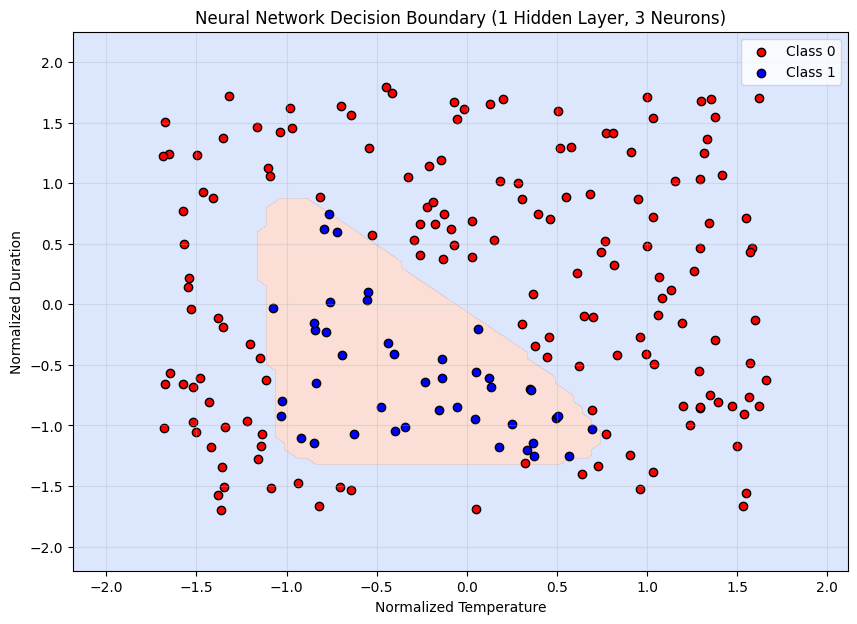

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Sigmoid Function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 2. Network Architecture Define karte hain
m, n = Xn.shape     # Input features (2)
hidden_units =10  # Hidden layer mein 3 neurons lagayenge
output_units = 1    # Output mein 1 neuron

# 3. Parameters Initialize karte hain (Ab do W aur do b honge)
np.random.seed(42)
W1 = np.random.randn(n, hidden_units) * 0.1  # Shape: (2, 3)
b1 = np.zeros((1, hidden_units))             # Shape: (1, 3)
W2 = np.random.randn(hidden_units, output_units) * 0.1  # Shape: (3, 1)
b2 = np.zeros((1, output_units))             # Shape: (1, 1)

# Hyperparameters (Learning rate thoda badha diya hai fast training ke liye)
learning_rate = 1.0
epochs = 5000

print("Training shuru ho rahi hai...\n")

# 4. Main Gradient Descent Loop
for i in range(epochs):
    
    # --- FORWARD PROPAGATION (2 Layers) ---
    Z1 = np.dot(Xn, W1) + b1        # Layer 1
    A1 = sigmoid(Z1)                # Hidden layer outputs
    
    Z2 = np.dot(A1, W2) + b2        # Layer 2 (Final)
    A2 = sigmoid(Z2)                # Final Prediction
    
    # --- COST CALCULATION ---
    if i % 1000 == 0:
        epsilon = 1e-15
        cost = -1/m * np.sum(y * np.log(A2 + epsilon) + (1 - y) * np.log(1 - A2 + epsilon))
        print(f"Epoch {i}: Cost = {cost:.4f}")
        
    # --- BACKWARD PROPAGATION (Chain Rule ka asli khel) ---
    # Output Layer Gradients
    dZ2 = A2 - y
    dW2 = (1/m) * np.dot(A1.T, dZ2)
    db2 = (1/m) * np.sum(dZ2, axis=0, keepdims=True)
    
    # Hidden Layer Gradients (Derivative of Sigmoid: A1 * (1 - A1))
    dZ1 = np.dot(dZ2, W2.T) * (A1 * (1 - A1))
    dW1 = (1/m) * np.dot(Xn.T, dZ1)
    db1 = (1/m) * np.sum(dZ1, axis=0, keepdims=True)
    
    # --- UPDATE PARAMETERS ---
    W1 = W1 - learning_rate * dW1
    b1 = b1 - learning_rate * db1
    W2 = W2 - learning_rate * dW2
    b2 = b2 - learning_rate * db2

print("\n--- Training Complete! ---")
print(f"Final Cost: {cost:.4f}\n")

# ==========================================
# 5. DECISION BOUNDARY PLOT KARNA
# ==========================================
print("Plotting Decision Boundary...")

# Ek grid banate hain pure graph cover karne ke liye
x_min, x_max = Xn[:, 0].min() - 0.5, Xn[:, 0].max() + 0.5
y_min, y_max = Xn[:, 1].min() - 0.5, Xn[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Grid ke har point par model ka prediction nikalte hain
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z1_grid = np.dot(grid_points, W1) + b1
A1_grid = sigmoid(Z1_grid)
Z2_grid = np.dot(A1_grid, W2) + b2
A2_grid = sigmoid(Z2_grid)

# 0.5 se upar ko Class 1, neeche ko Class 0 mante hain
Z_pred = (A2_grid > 0.5).reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z_pred, alpha=0.3, cmap="coolwarm")
plt.scatter(Xn[y.flatten() == 0][:, 0], Xn[y.flatten() == 0][:, 1], color="red", label="Class 0", edgecolors='k')
plt.scatter(Xn[y.flatten() == 1][:, 0], Xn[y.flatten() == 1][:, 1], color="blue", label="Class 1", edgecolors='k')
plt.title("Neural Network Decision Boundary (1 Hidden Layer, 3 Neurons)")
plt.xlabel("Normalized Temperature")
plt.ylabel("Normalized Duration")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()